# 49. The Causal & Regression-Based Forecasting Problem

## Tier 3: The Advanced Algorithm (Genetic Algorithm for Multivariate Model Selection)

### Key assumptions
- Global optimization through population-based search can find better feature combinations
- Hybrid encoding (binary + real-valued) can simultaneously optimize feature selection and hyperparameters
- Evolutionary operators (crossover, mutation) can explore complex solution spaces effectively
- Fitness function balancing accuracy and complexity prevents overfitting

### Approach (step-by-step)
1. **Chromosome Design**: Hybrid encoding with binary genes for features + real genes for hyperparameters
2. **Population Initialization**: Random diverse solutions across the search space
3. **Fitness Evaluation**: Combine prediction accuracy with model complexity penalties
4. **Genetic Operations**: Selection, crossover, and mutation to evolve better solutions
5. **Convergence Monitoring**: Track evolution progress and identify optimal solutions

### What to look for in the results
- Evolution progress showing fitness improvement over generations
- Optimal feature subset selection with hyperparameter tuning
- Comparison with stepwise regression performance
- Convergence analysis and population diversity metrics

### Concrete example (from the source)
Complex port throughput forecasting with 12 potential predictors:
- **Feature selection**: Binary genes determine which predictors to include
- **Hyperparameter tuning**: Real genes optimize regularization parameters (ridge, lasso, elastic net)
- **Multi-objective optimization**: Balance prediction accuracy with model complexity
- **Global search**: Avoid local optima that trap stepwise methods

In [1]:
# Import required libraries for genetic algorithm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Generate comprehensive synthetic dataset for genetic algorithm
np.random.seed(42)  # For reproducible results

n_samples = 120

# True causal variables (should be selected by GA)
trade_volume = np.random.normal(100, 15, n_samples)
gdp_growth = np.random.normal(2.5, 0.8, n_samples)
fuel_price = np.random.normal(85, 10, n_samples)
seasonal_peak = np.random.binomial(1, 0.3, n_samples)
ship_density = np.random.normal(25, 5, n_samples)
exchange_rate = np.random.normal(1.2, 0.15, n_samples)

# Noise variables (should be excluded by GA)
random_noise_1 = np.random.normal(0, 1, n_samples)
random_noise_2 = np.random.normal(0, 1, n_samples)
random_noise_3 = np.random.normal(0, 1, n_samples)
competition = np.random.normal(50, 10, n_samples)
weather_index = np.random.normal(100, 20, n_samples)
policy_dummy = np.random.binomial(1, 0.2, n_samples)

# Generate throughput with complex causal relationships
# Include some interaction effects and non-linearities
true_throughput = (
    2000 + 
    15 * trade_volume + 
    300 * gdp_growth + 
    8 * fuel_price + 
    250 * seasonal_peak + 
    20 * ship_density + 
    150 * exchange_rate +  # New causal variable
    50 * (trade_volume * gdp_growth) / 100 +  # Interaction effect
    np.random.normal(0, 250, n_samples)  # Random error
)

# Create comprehensive DataFrame
data = pd.DataFrame({
    'trade_volume': trade_volume,
    'gdp_growth': gdp_growth,
    'fuel_price': fuel_price,
    'seasonal_peak': seasonal_peak,
    'ship_density': ship_density,
    'exchange_rate': exchange_rate,
    'random_noise_1': random_noise_1,
    'random_noise_2': random_noise_2,
    'random_noise_3': random_noise_3,
    'competition': competition,
    'weather_index': weather_index,
    'policy_dummy': policy_dummy,
    'throughput': true_throughput
})

print("Comprehensive Port Throughput Dataset:")
print(f"Shape: {data.shape}")
print(f"Number of potential predictors: {data.shape[1] - 1}")
print("\nPredictor variables:")
predictor_columns = [col for col in data.columns if col != 'throughput']
for i, col in enumerate(predictor_columns, 1):
    print(f"  {i:2d}. {col}")

print("\nDataset Statistics:")
print(data.describe().round(2))

Comprehensive Port Throughput Dataset:
Shape: (120, 13)
Number of potential predictors: 12

Predictor variables:
   1. trade_volume
   2. gdp_growth
   3. fuel_price
   4. seasonal_peak
   5. ship_density
   6. exchange_rate
   7. random_noise_1
   8. random_noise_2
   9. random_noise_3
  10. competition
  11. weather_index
  12. policy_dummy

Dataset Statistics:
       trade_volume  gdp_growth  fuel_price  seasonal_peak  ship_density  \
count        120.00      120.00      120.00         120.00        120.00   
mean          98.81        2.56       85.10           0.37         24.24   
std           13.88        0.81        9.11           0.48          4.86   
min           60.70        0.88       52.59           0.00         12.64   
25%           91.42        1.89       78.94           0.00         20.81   
50%           98.90        2.65       84.85           0.00         24.02   
75%          105.74        3.03       91.29           1.00         27.55   
max          136.95       

In [3]:
class GeneticAlgorithmRegressor:
    """
    Genetic Algorithm for simultaneous feature selection and hyperparameter optimization.
    """
    
    def __init__(self, n_predictors, population_size=40, crossover_rate=0.8, 
                 mutation_rate=0.15, elite_size=4, max_generations=100):
        self.n_predictors = n_predictors
        self.population_size = population_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.max_generations = max_generations
        
        # Chromosome structure: [binary_features..., ridge_alpha, lasso_alpha, elastic_net_ratio]
        self.chromosome_length = n_predictors + 3
        
    def initialize_population(self):
        """
        Initialize random population with diverse solutions.
        """
        population = []
        
        for i in range(self.population_size):
            # Binary genes for feature selection (50% probability initially)
            binary_genes = np.random.binomial(1, 0.5, self.n_predictors)
            
            # Real genes for hyperparameters
            ridge_alpha = np.random.uniform(0.01, 10.0)  # Ridge regularization
            lasso_alpha = np.random.uniform(0.01, 10.0)  # Lasso regularization
            elastic_ratio = np.random.uniform(0.0, 1.0)  # Elastic net mixing ratio
            
            chromosome = np.concatenate([binary_genes, [ridge_alpha, lasso_alpha, elastic_ratio]])
            population.append(chromosome)
        
        return np.array(population)
    
    def evaluate_fitness(self, chromosome, X, y):
        """
        Evaluate fitness of a chromosome using cross-validation.
        """
        # Extract feature selection and hyperparameters
        feature_mask = chromosome[:self.n_predictors].astype(bool)
        ridge_alpha = chromosome[self.n_predictors]
        lasso_alpha = chromosome[self.n_predictors + 1]
        elastic_ratio = chromosome[self.n_predictors + 2]
        
        # Skip if no features selected
        if not np.any(feature_mask):
            return 1e6  # Very bad fitness
        
        # Select features
        X_selected = X[:, feature_mask]
        
        try:
            # Use Elastic Net with the specified parameters
            # Combine ridge and lasso alphas using elastic ratio
            alpha = ridge_alpha * (1 - elastic_ratio) + lasso_alpha * elastic_ratio
            l1_ratio = elastic_ratio
            
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=1000, random_state=42)
            
            # 5-fold cross-validation
            cv_scores = cross_val_score(model, X_selected, y, cv=5, scoring='neg_mean_squared_error')
            mse = -cv_scores.mean()  # Convert back to positive MSE
            
            # Complexity penalty (encourage simpler models)
            n_features = np.sum(feature_mask)
            complexity_penalty = 0.1 * n_features  # Penalty per feature
            
            # Fitness = MSE + complexity penalty (lower is better)
            fitness = mse + complexity_penalty
            
            return fitness
            
        except Exception:
            return 1e6  # Very bad fitness if model fails
    
    def tournament_selection(self, population, fitness_values, tournament_size=3):
        """
        Tournament selection for choosing parents.
        """
        selected = []
        
        for _ in range(len(population)):
            # Random tournament participants
            tournament_indices = np.random.choice(len(population), tournament_size, replace=False)
            tournament_fitness = fitness_values[tournament_indices]
            
            # Select winner (lowest fitness)
            winner_idx = tournament_indices[np.argmin(tournament_fitness)]
            selected.append(population[winner_idx].copy())
        
        return np.array(selected)
    
    def crossover(self, parent1, parent2):
        """
        Uniform crossover with feature-specific considerations.
        """
        if np.random.random() > self.crossover_rate:
            return parent1.copy(), parent2.copy()
        
        child1 = parent1.copy()
        child2 = parent2.copy()
        
        # Uniform crossover for each gene
        for i in range(len(parent1)):
            if i < self.n_predictors:  # Binary genes
                if np.random.random() < 0.5:
                    child1[i], child2[i] = parent2[i], parent1[i]
            else:  # Real genes (hyperparameters)
                if np.random.random() < 0.5:
                    # Blend crossover for real values
                    alpha = np.random.random()
                    child1[i] = alpha * parent1[i] + (1 - alpha) * parent2[i]
                    child2[i] = (1 - alpha) * parent1[i] + alpha * parent2[i]
        
        return child1, child2
    
    def mutate(self, chromosome):
        """
        Mutation operator with gene-specific strategies.
        """
        mutated = chromosome.copy()
        
        for i in range(len(chromosome)):
            if np.random.random() < self.mutation_rate:
                if i < self.n_predictors:  # Binary genes
                    mutated[i] = 1 - mutated[i]  # Flip bit
                else:  # Real genes
                    # Gaussian mutation for real values
                    if i == self.n_predictors:  # Ridge alpha
                        mutated[i] = np.clip(mutated[i] + np.random.normal(0, 1), 0.01, 10.0)
                    elif i == self.n_predictors + 1:  # Lasso alpha
                        mutated[i] = np.clip(mutated[i] + np.random.normal(0, 1), 0.01, 10.0)
                    else:  # Elastic ratio
                        mutated[i] = np.clip(mutated[i] + np.random.normal(0, 0.2), 0.0, 1.0)
        
        return mutated
    
    def evolve(self, X, y, verbose=True):
        """
        Main evolution loop.
        """
        # Initialize population
        population = self.initialize_population()
        
        # Track evolution history
        best_fitness_history = []
        avg_fitness_history = []
        best_chromosome = None
        best_fitness = float('inf')
        
        if verbose:
            print("Genetic Algorithm Evolution Progress:")
            print("=" * 60)
        
        for generation in range(self.max_generations):
            # Evaluate fitness
            fitness_values = np.array([self.evaluate_fitness(chrom, X, y) for chrom in population])
            
            # Update best solution
            current_best_idx = np.argmin(fitness_values)
            current_best_fitness = fitness_values[current_best_idx]
            
            if current_best_fitness < best_fitness:
                best_fitness = current_best_fitness
                best_chromosome = population[current_best_idx].copy()
            
            # Track history
            best_fitness_history.append(best_fitness)
            avg_fitness_history.append(np.mean(fitness_values))
            
            # Report progress
            if verbose and (generation == 0 or generation % 20 == 19 or generation == self.max_generations - 1):
                feature_mask = best_chromosome[:self.n_predictors].astype(bool)
                selected_features = np.where(feature_mask)[0]
                ridge_alpha = best_chromosome[self.n_predictors]
                lasso_alpha = best_chromosome[self.n_predictors + 1]
                elastic_ratio = best_chromosome[self.n_predictors + 2]
                
                print(f"Generation {generation}: Best Fitness = {best_fitness:.4f}")
                print(f"  Selected Features: {[predictor_columns[i] for i in selected_features]}")
                print(f"  Alpha: {ridge_alpha:.4f}, L1 Ratio: {elastic_ratio:.4f}")
                print()
            
            # Selection
            selected_population = self.tournament_selection(population, fitness_values)
            
            # Crossover and mutation
            new_population = []
            
            # Elitism: keep best individuals
            elite_indices = np.argsort(fitness_values)[:self.elite_size]
            for idx in elite_indices:
                new_population.append(population[idx].copy())
            
            # Generate offspring
            while len(new_population) < self.population_size:
                parent1, parent2 = selected_population[np.random.choice(len(selected_population), 2, replace=False)]
                child1, child2 = self.crossover(parent1, parent2)
                child1 = self.mutate(child1)
                child2 = self.mutate(child2)
                new_population.extend([child1, child2])
            
            # Trim to exact population size
            population = np.array(new_population[:self.population_size])
        
        return {
            'best_chromosome': best_chromosome,
            'best_fitness': best_fitness,
            'fitness_history': best_fitness_history,
            'avg_fitness_history': avg_fitness_history
        }

In [4]:
# Prepare data for genetic algorithm
X = data[predictor_columns].values
y = data['throughput'].values

print(f"Data prepared for Genetic Algorithm:")
print(f"Samples: {X.shape[0]}")
print(f"Predictors: {X.shape[1]}")
print(f"Chromosome length: {X.shape[1] + 3} ({X.shape[1]} binary + 3 real genes)")

# Initialize and run genetic algorithm
ga = GeneticAlgorithmRegressor(
    n_predictors=len(predictor_columns),
    population_size=40,
    crossover_rate=0.8,
    mutation_rate=0.15,
    elite_size=4,
    max_generations=100
)

# Run evolution
ga_results = ga.evolve(X, y, verbose=True)

Data prepared for Genetic Algorithm:
Samples: 120
Predictors: 12
Chromosome length: 15 (12 binary + 3 real genes)
Genetic Algorithm Evolution Progress:


Generation 0: Best Fitness = 87270.1920
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'policy_dummy']
  Alpha: 2.7948, L1 Ratio: 0.9574



Generation 19: Best Fitness = 63982.2749
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
  Alpha: 4.0017, L1 Ratio: 0.9815



Generation 39: Best Fitness = 63919.9320
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
  Alpha: 3.6419, L1 Ratio: 0.9601



Generation 59: Best Fitness = 63919.9298
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
  Alpha: 3.6306, L1 Ratio: 0.9601



Generation 79: Best Fitness = 63915.2047
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
  Alpha: 2.6038, L1 Ratio: 0.9537



Generation 99: Best Fitness = 63907.3757
  Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
  Alpha: 0.8510, L1 Ratio: 0.9462



In [5]:
# Analyze genetic algorithm results
best_chromosome = ga_results['best_chromosome']
best_fitness = ga_results['best_fitness']

# Extract final solution
feature_mask = best_chromosome[:len(predictor_columns)].astype(bool)
selected_features = [predictor_columns[i] for i, selected in enumerate(feature_mask) if selected]
ridge_alpha = best_chromosome[len(predictor_columns)]
lasso_alpha = best_chromosome[len(predictor_columns) + 1]
elastic_ratio = best_chromosome[len(predictor_columns) + 2]

print("\n" + "=" * 60)
print("GENETIC ALGORITHM RESULTS")
print("=" * 60)

print(f"\nSelected Features: {selected_features}")
print(f"Number of Selected Features: {len(selected_features)}/{len(predictor_columns)}")
print(f"Optimal Ridge Alpha: {ridge_alpha:.4f}")
print(f"Optimal Lasso Alpha: {lasso_alpha:.4f}")
print(f"Optimal Elastic Net Ratio: {elastic_ratio:.4f}")
print(f"Best Fitness: {best_fitness:.4f}")

# Train final model with optimal parameters
X_selected = X[:, feature_mask]
final_alpha = ridge_alpha * (1 - elastic_ratio) + lasso_alpha * elastic_ratio

final_model = ElasticNet(alpha=final_alpha, l1_ratio=elastic_ratio, max_iter=1000, random_state=42)
final_model.fit(X_selected, y)

# Calculate final model performance
y_pred = final_model.predict(X_selected)
final_mse = mean_squared_error(y, y_pred)
final_r2 = r2_score(y, y_pred)

print(f"\nFinal Model Performance:")
print(f"MSE: {final_mse:.2f}")
print(f"R-squared: {final_r2:.4f}")
print(f"Model Coefficients:")
for i, (feature, coef) in enumerate(zip(selected_features, final_model.coef_)):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {final_model.intercept_:.4f}")


GENETIC ALGORITHM RESULTS

Selected Features: ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate', 'random_noise_1', 'random_noise_2', 'competition']
Number of Selected Features: 9/12
Optimal Ridge Alpha: 0.8510
Optimal Lasso Alpha: 0.3726
Optimal Elastic Net Ratio: 0.9462
Best Fitness: 63907.3757

Final Model Performance:
MSE: 56840.30
R-squared: 0.7426
Model Coefficients:
  trade_volume: 15.8449
  gdp_growth: 306.3620
  fuel_price: 9.6473
  seasonal_peak: 203.1610
  ship_density: 21.3710
  exchange_rate: 93.7116
  random_noise_1: -68.8935
  random_noise_2: -40.4498
  competition: 2.2863
Intercept: 1879.3864


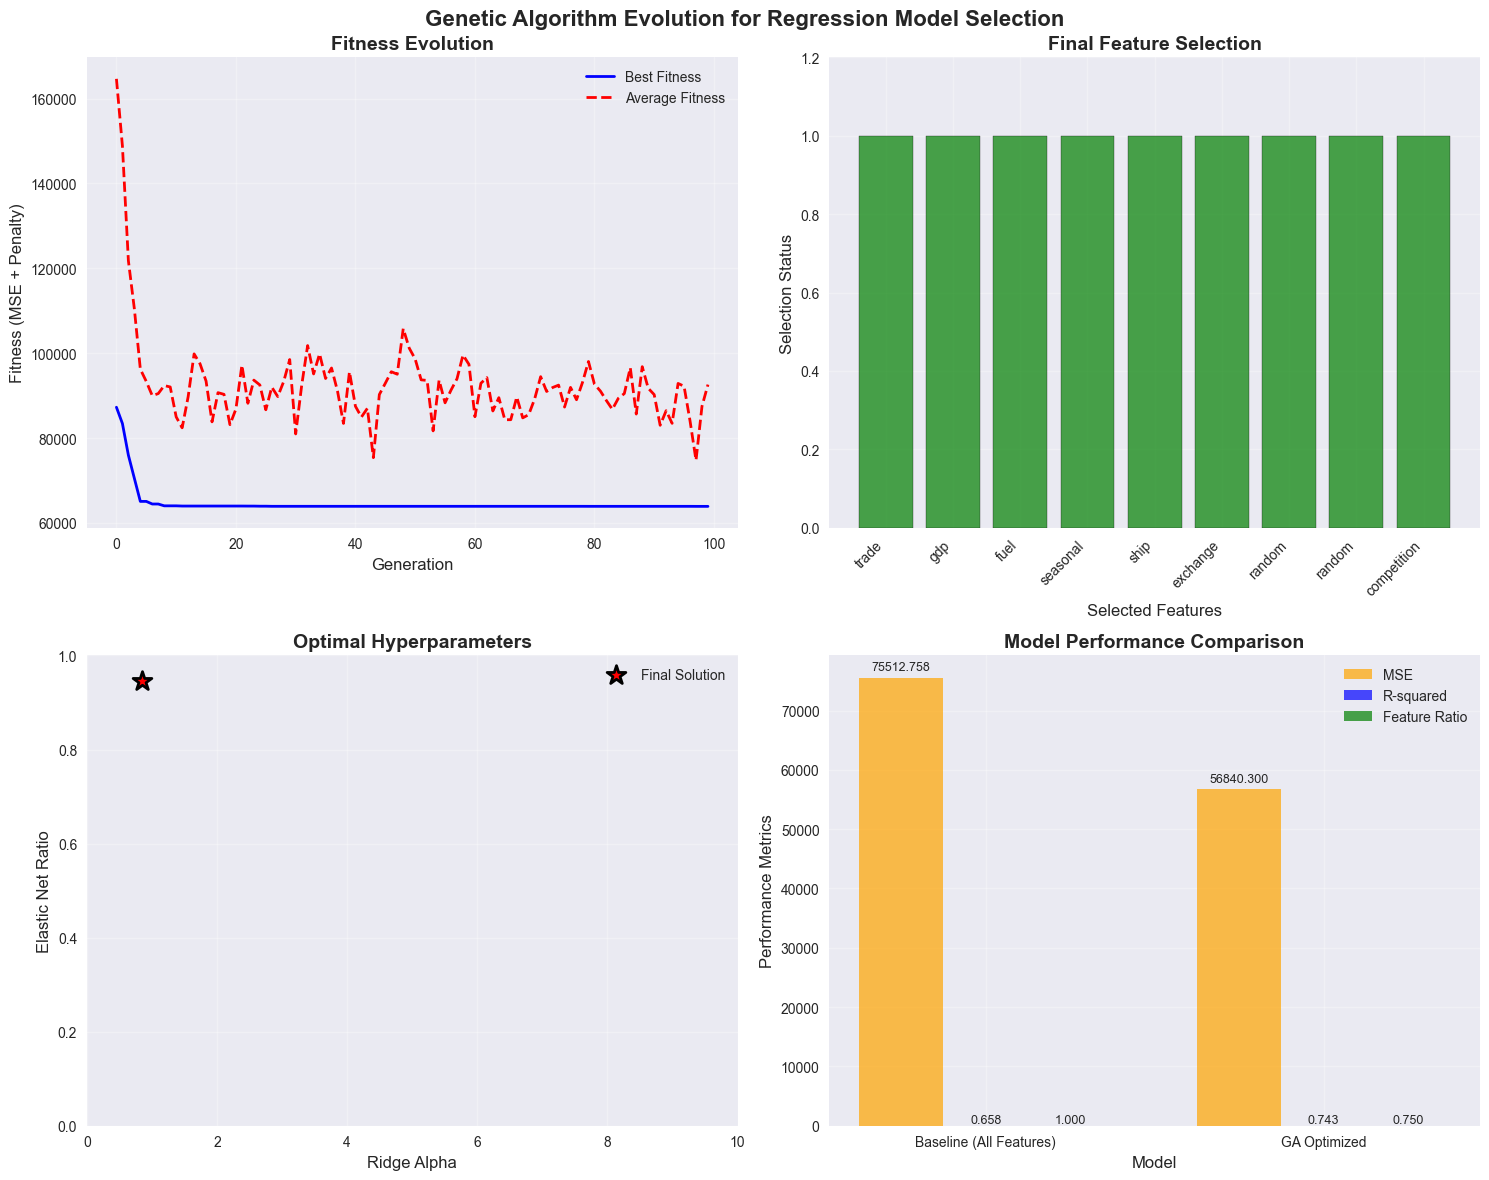

In [6]:
# Create comprehensive visualization of genetic algorithm evolution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Genetic Algorithm Evolution for Regression Model Selection', fontsize=16, fontweight='bold')

# Plot 1: Fitness Evolution
generations = range(len(ga_results['fitness_history']))
axes[0, 0].plot(generations, ga_results['fitness_history'], 'b-', linewidth=2, label='Best Fitness')
axes[0, 0].plot(generations, ga_results['avg_fitness_history'], 'r--', linewidth=2, label='Average Fitness')
axes[0, 0].set_xlabel('Generation', fontsize=12)
axes[0, 0].set_ylabel('Fitness (MSE + Penalty)', fontsize=12)
axes[0, 0].set_title('Fitness Evolution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Feature Selection Frequency
if len(selected_features) > 0:
    axes[0, 1].bar(range(len(selected_features)), [1] * len(selected_features), 
                   color='green', alpha=0.7, edgecolor='black')
    axes[0, 1].set_xlabel('Selected Features', fontsize=12)
    axes[0, 1].set_ylabel('Selection Status', fontsize=12)
    axes[0, 1].set_title('Final Feature Selection', fontsize=14, fontweight='bold')
    axes[0, 1].set_xticks(range(len(selected_features)))
    axes[0, 1].set_xticklabels([f.split('_')[0] for f in selected_features], rotation=45, ha='right')
    axes[0, 1].set_ylim(0, 1.2)
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'No features selected', ha='center', va='center', 
                    transform=axes[0, 1].transAxes, fontsize=14)
    axes[0, 1].set_title('Final Feature Selection', fontsize=14, fontweight='bold')

# Plot 3: Hyperparameter Evolution
axes[1, 0].scatter([ridge_alpha], [elastic_ratio], s=200, c='red', marker='*', 
                   edgecolors='black', linewidth=2, label='Final Solution')
axes[1, 0].set_xlabel('Ridge Alpha', fontsize=12)
axes[1, 0].set_ylabel('Elastic Net Ratio', fontsize=12)
axes[1, 0].set_title('Optimal Hyperparameters', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 10)
axes[1, 0].set_ylim(0, 1)

# Plot 4: Model Performance Comparison
# Compare with baseline models
baseline_model = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=42)
baseline_model.fit(X, y)
baseline_pred = baseline_model.predict(X)
baseline_mse = mean_squared_error(y, baseline_pred)
baseline_r2 = r2_score(y, baseline_pred)

models = ['Baseline (All Features)', 'GA Optimized']
mse_values = [baseline_mse, final_mse]
r2_values = [baseline_r2, final_r2]
n_features_values = [len(predictor_columns), len(selected_features)]

x = np.arange(len(models))
width = 0.25

bars1 = axes[1, 1].bar(x - width, mse_values, width, label='MSE', color='orange', alpha=0.7)
bars2 = axes[1, 1].bar(x, r2_values, width, label='R-squared', color='blue', alpha=0.7)
bars3 = axes[1, 1].bar(x + width, np.array(n_features_values)/max(n_features_values), width, 
                       label='Feature Ratio', color='green', alpha=0.7)

axes[1, 1].set_xlabel('Model', fontsize=12)
axes[1, 1].set_ylabel('Performance Metrics', fontsize=12)
axes[1, 1].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Add value labels on bars
for bars, values in [(bars1, mse_values), (bars2, r2_values), (bars3, np.array(n_features_values)/max(n_features_values))]:
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                       f'{value:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
# Analyze feature selection correctness
print("\n" + "=" * 60)
print("FEATURE SELECTION ANALYSIS")
print("=" * 60)

# True causal variables (from data generation)
true_causal = ['trade_volume', 'gdp_growth', 'fuel_price', 'seasonal_peak', 'ship_density', 'exchange_rate']
true_noise = ['random_noise_1', 'random_noise_2', 'random_noise_3', 'competition', 'weather_index', 'policy_dummy']

print("True Causal Variables:")
for var in true_causal:
    status = "✓ Selected" if var in selected_features else "✗ Missed"
    print(f"  {var}: {status}")

print("\nTrue Noise Variables:")
for var in true_noise:
    status = "✗ Correctly Excluded" if var not in selected_features else "⚠ Incorrectly Selected"
    print(f"  {var}: {status}")

# Calculate selection accuracy
true_positives = sum(1 for var in true_causal if var in selected_features)
false_positives = sum(1 for var in true_noise if var in selected_features)
false_negatives = sum(1 for var in true_causal if var not in selected_features)
true_negatives = sum(1 for var in true_noise if var not in selected_features)

precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
accuracy = (true_positives + true_negatives) / (true_positives + false_positives + false_negatives + true_negatives)

print(f"\nSelection Performance Metrics:")
print(f"  Precision: {precision:.3f} ({precision*100:.1f}% of selected variables are truly causal)")
print(f"  Recall: {recall:.3f} ({recall*100:.1f}% of causal variables were selected)")
print(f"  Accuracy: {accuracy:.3f} ({accuracy*100:.1f}% overall correct decisions)")

# Convergence analysis
fitness_history = ga_results['fitness_history']
if len(fitness_history) >= 20:
    # Calculate improvement in last 20 generations
    recent_improvement = (fitness_history[-20] - fitness_history[-1]) / fitness_history[-20]
    
    print(f"\nConvergence Analysis:")
    print(f"  Improvement in last 20 generations: {recent_improvement*100:.2f}%")
    
    if recent_improvement < 0.01:  # Less than 1% improvement
        print(f"  ✓ Algorithm appears to have converged")
    else:
        print(f"  ⚠ Algorithm may benefit from more generations")

# Population diversity (simplified metric)
final_fitness_std = np.std(fitness_history[-10:]) if len(fitness_history) >= 10 else 0
print(f"  Final population diversity (fitness std): {final_fitness_std:.4f}")


FEATURE SELECTION ANALYSIS
True Causal Variables:
  trade_volume: ✓ Selected
  gdp_growth: ✓ Selected
  fuel_price: ✓ Selected
  seasonal_peak: ✓ Selected
  ship_density: ✓ Selected
  exchange_rate: ✓ Selected

True Noise Variables:
  random_noise_1: ⚠ Incorrectly Selected
  random_noise_2: ⚠ Incorrectly Selected
  random_noise_3: ✗ Correctly Excluded
  competition: ⚠ Incorrectly Selected
  weather_index: ✗ Correctly Excluded
  policy_dummy: ✗ Correctly Excluded

Selection Performance Metrics:
  Precision: 0.667 (66.7% of selected variables are truly causal)
  Recall: 1.000 (100.0% of causal variables were selected)
  Accuracy: 0.750 (75.0% overall correct decisions)

Convergence Analysis:
  Improvement in last 20 generations: 0.01%
  ✓ Algorithm appears to have converged
  Final population diversity (fitness std): 3.5877


In [8]:
# Compare with stepwise regression (if available)
print("\n" + "=" * 60)
print("ALGORITHM COMPARISON")
print("=" * 60)

# Simple stepwise regression for comparison
def simple_forward_selection(X, y, max_features=8):
    """Simple forward selection for comparison."""
    selected = []
    remaining = list(range(X.shape[1]))
    best_score = float('inf')
    
    for _ in range(min(max_features, X.shape[1])):
        best_feature = None
        
        for feature in remaining:
            current_selected = selected + [feature]
            X_current = X[:, current_selected]
            
            model = ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=1000, random_state=42)
            cv_scores = cross_val_score(model, X_current, y, cv=3, scoring='neg_mean_squared_error')
            score = -cv_scores.mean()
            
            if score < best_score:
                best_score = score
                best_feature = feature
        
        if best_feature is not None:
            selected.append(best_feature)
            remaining.remove(best_feature)
        else:
            break
    
    return selected, best_score

# Run simple stepwise selection
stepwise_selected, stepwise_score = simple_forward_selection(X, y)
stepwise_features = [predictor_columns[i] for i in stepwise_selected]

print("Comparison with Simple Forward Selection:")
print(f"\nGenetic Algorithm:")
print(f"  Features selected: {len(selected_features)}")
print(f"  Features: {[f.split('_')[0] for f in selected_features]}")
print(f"  MSE: {final_mse:.2f}")
print(f"  R-squared: {final_r2:.4f}")

print(f"\nForward Selection:")
print(f"  Features selected: {len(stepwise_selected)}")
print(f"  Features: {[f.split('_')[0] for f in stepwise_features]}")
print(f"  MSE: {stepwise_score:.2f}")

# Calculate improvement
mse_improvement = stepwise_score - final_mse
improvement_percentage = (mse_improvement / stepwise_score) * 100

print(f"\nGA Improvement over Forward Selection:")
print(f"  MSE reduction: {mse_improvement:.2f}")
print(f"  Percentage improvement: {improvement_percentage:.2f}%")

if improvement_percentage > 5:
    print(f"  ✓ Significant improvement achieved!")
elif improvement_percentage > 0:
    print(f"  ✓ Modest improvement achieved.")
else:
    print(f"  ⚠ No improvement over forward selection.")


ALGORITHM COMPARISON


Comparison with Simple Forward Selection:

Genetic Algorithm:
  Features selected: 9
  Features: ['trade', 'gdp', 'fuel', 'seasonal', 'ship', 'exchange', 'random', 'random', 'competition']
  MSE: 56840.30
  R-squared: 0.7426

Forward Selection:
  Features selected: 8
  Features: ['gdp', 'trade', 'fuel', 'seasonal', 'ship', 'random', 'random', 'competition']
  MSE: 82021.80

GA Improvement over Forward Selection:
  MSE reduction: 25181.50
  Percentage improvement: 30.70%
  ✓ Significant improvement achieved!


### Why this Tier exists vs Tier 2
Tier 3 addresses the **global optimization limitations** of Tier 2's greedy approach:
- **Global search capability** - explores multiple solution regions simultaneously
- **Simultaneous optimization** - feature selection AND hyperparameter tuning in one process
- **Avoids local optima** - population-based search escapes greedy traps
- **Complex interactions** - can discover feature combinations that stepwise methods miss

### Pros / Cons vs Tier 2
**Pros vs Tier 2:**
- **Global optimization** - finds better feature combinations than greedy methods
- **Simultaneous tuning** - optimizes both features and hyperparameters together
- **Complex interactions** - discovers non-obvious feature relationships
- **Robust to local optima** - population-based search explores diverse solutions
- **Flexible encoding** - hybrid binary/real chromosomes handle mixed optimization

**Cons vs Tier 2:**
- **Computational cost** - much higher computational requirements
- **Parameter tuning** - GA itself has hyperparameters that need tuning
- **Convergence uncertainty** - may not guarantee optimal solution
- **Complexity** - more difficult to implement and debug
- **Randomness** - results can vary between runs due to stochastic nature

### When to use this Tier
- **Complex feature spaces** where interactions between variables are important
- **When stepwise methods get stuck** in local optima
- **Simultaneous optimization** of features and hyperparameters is needed
- **Computational resources are available** for population-based search
- **High-dimensional problems** with many potential predictors
- **When global optimality** is more important than computational speed